<a href="https://colab.research.google.com/github/ONL3-AIS2-S5-Team-4/Real-Time-Object-Detection-for-Autonomous-Vehicles/blob/FahdAdly-patch-1/Milestone_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🚗 Project 4: Real-Time Object Detection for Autonomous Vehicles
## Milestone 1: Data Collection, Exploration, Preprocessing, and Class-Aware Augmentation

**Objective:**
The primary goal is to construct a high-quality, balanced dataset for training the autonomous driving object detection model. This notebook implements:
1.  **Data Collection** (Roboflow Download)
2.  **Data Exploration & Analysis** (Class Distribution)
3.  **Preprocessing** (Resizing/Normalization)
4.  **Class-Aware Augmentation** (To mitigate class imbalance)
5.  **Quality Assurance & Final Packaging**

**Important:** Replace `YOUR_API_KEY` or set the `ROBOFLOW_API_KEY` environment variable before running the download cell.


In [1]:

# Environment setup - run once
!pip install roboflow albumentations opencv-python tqdm matplotlib pandas seaborn pyyaml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 36.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:

from roboflow import Roboflow
import os

# --- CONFIGURATION (UPDATE THESE) ---
API_KEY = os.getenv("ROBOFLOW_API_KEY", "566r25x43JupkeFgvfe7")
WORKSPACE_SLUG = "fahd-91jem"
PROJECT_SLUG = "self-driving-cars-che0a-qctzy"
VERSION_NUMBER = 1
FORMAT = "yolov8"

dataset = None
if API_KEY != "YOUR_API_KEY":
    try:
        rf = Roboflow(api_key=API_KEY)
        project = rf.workspace(WORKSPACE_SLUG).project(PROJECT_SLUG)
        version = project.version(VERSION_NUMBER)
        dataset = version.download(FORMAT)
        print(f"✅ Dataset downloaded to: {dataset.location}")
    except Exception as e:
        print("❗ Roboflow download failed:", e)
        dataset = None
else:
    print("⚠️ Skipped Roboflow download — set ROBOFLOW_API_KEY env var or replace API_KEY.")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Self-Driving-Cars-1 in yolov8:: 100%|██████████| 35120/35120 [00:05<00:00, 6039.19it/s]

✅ Dataset downloaded to: /content/Self-Driving-Cars-1


Dataset location set to: /content/Self-Driving-Cars-1
📋 Classes found: ['0', '1', '10', '2', '3', '4', '5', '6', '7', '8', '9']




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



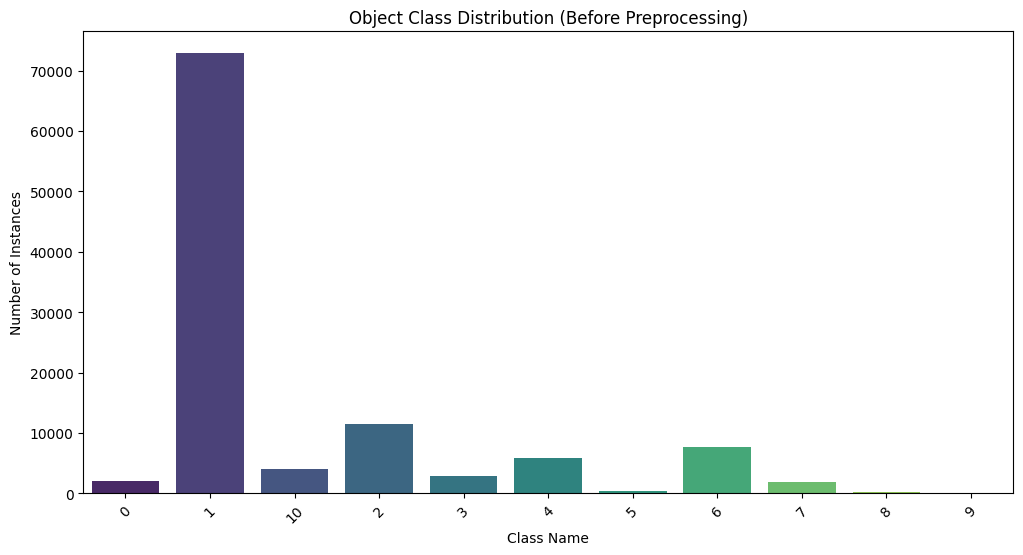

In [3]:

import glob
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import shutil
from collections import Counter
import os

# --- PATHS ---
dataset_location = getattr(dataset, "location", None)
if dataset_location is None:
    # Fallback/Manual setting if download skipped
    default_location = f"{PROJECT_SLUG}-{VERSION_NUMBER}-{FORMAT}"
    if os.path.exists(default_location):
        dataset_location = default_location
    else:
        raise RuntimeError("Dataset not found. Set dataset_location manually or run Roboflow download.")

print(f"Dataset location set to: {dataset_location}")

train_images_path = os.path.join(dataset_location, "train", "images")
train_labels_path = os.path.join(dataset_location, "train", "labels")
data_yaml_path = os.path.join(dataset_location, "data.yaml")

# --- LOAD CLASSES ---
with open(data_yaml_path, 'r') as stream:
    data_info = yaml.safe_load(stream)
class_names = data_info.get('names', {})
if isinstance(class_names, dict):
    class_names = [v for k, v in sorted(class_names.items(), key=lambda kv: int(kv[0]))]
print(f"📋 Classes found: {class_names}")

# --- DATA EXPLORATION (Initial Counts) ---
class_counts = Counter({name: 0 for name in class_names})
label_files = glob.glob(os.path.join(train_labels_path, "*.txt"))
for l_file in label_files:
    with open(l_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts: continue
            try:
                cls_id = int(float(parts[0]))
                if 0 <= cls_id < len(class_names):
                    class_counts[class_names[cls_id]] += 1
            except:
                continue

# Visualize distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(class_counts.keys()), y=[class_counts[k] for k in class_counts.keys()], palette="viridis")
plt.title("Object Class Distribution (Before Preprocessing)")
plt.xlabel("Class Name")
plt.ylabel("Number of Instances")
plt.xticks(rotation=45)
plt.show()


In [4]:

# --- PREPROCESSING: RESIZE & COPY LABELS ---
# This step ensures all images are uniformly sized before augmentation.
PREPROCESS_SIZE = 416
preprocessed_img_dir = os.path.join(dataset_location, "train", "images_preprocessed")
preprocessed_lbl_dir = os.path.join(dataset_location, "train", "labels_preprocessed")
os.makedirs(preprocessed_img_dir, exist_ok=True)
os.makedirs(preprocessed_lbl_dir, exist_ok=True)

print(f"⚙️ Starting preprocessing: resizing to {PREPROCESS_SIZE}x{PREPROCESS_SIZE}")
for img_file in glob.glob(os.path.join(train_images_path, "*.*")):
    if not img_file.lower().endswith((".jpg", ".jpeg", ".png")): continue
    base = os.path.splitext(os.path.basename(img_file))[0]
    img = cv2.imread(img_file)
    if img is None: continue
    if img.ndim == 2: img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Resize image.
    img_resized = cv2.resize(img, (PREPROCESS_SIZE, PREPROCESS_SIZE))

    cv2.imwrite(os.path.join(preprocessed_img_dir, f"{base}.jpg"), img_resized)

    # Copy label file (YOLO labels are already normalized 0-1)
    lbl_file = os.path.join(train_labels_path, f"{base}.txt")
    if os.path.exists(lbl_file): shutil.copy2(lbl_file, os.path.join(preprocessed_lbl_dir, f"{base}.txt"))
    else: open(os.path.join(preprocessed_lbl_dir, f"{base}.txt"), 'w').close()

print("✅ Preprocessing finished.")


⚙️ Starting preprocessing: resizing to 416x416
✅ Preprocessing finished.


In [9]:
import albumentations as A, cv2, os, math, yaml, glob; from tqdm import tqdm
import random; random.seed(42)

# --- CONFIG & DIRECTORIES ---
if 'dataset' not in locals(): raise RuntimeError("Dataset variable missing.")
DATA = dataset.location
MAX_AUG_FACTOR = 10  # Limit augmentation to max 10x per image
IMG_DIR, LBL_DIR = f"{DATA}/train/images", f"{DATA}/train/labels"
OUT_IMG, OUT_LBL = f"{DATA}/train/images_aug_classaware", f"{DATA}/train/labels_aug_classaware"
os.makedirs(OUT_IMG, exist_ok=True); os.makedirs(OUT_LBL, exist_ok=True)

# --- 1. CALCULATE FACTORS ---
print("📊 Calculating class factors...")
with open(f"{DATA}/data.yaml") as f: names = yaml.safe_load(f)['names']
counts = {i: 0 for i in range(len(names))}
for f in glob.glob(f"{LBL_DIR}/*.txt"):
    if os.path.getsize(f):
        for l in open(f):
            p = l.split()
            if p and p[0].isdigit(): counts[int(p[0])] += 1

valid = {k: v for k, v in counts.items() if v > 0}
max_c = max(valid.values()) if valid else 0
# Cap factors at MAX_AUG_FACTOR
factors = {k: min(MAX_AUG_FACTOR, math.ceil(max_c/v)) for k, v in valid.items()}
print(f"📈 Top Augmentation Factors (Max {MAX_AUG_FACTOR}x): {sorted(factors.items(), key=lambda x:x[1], reverse=True)[:5]}")

# --- 2. PIPELINE ---
aug = A.Compose([
    A.Affine(translate_percent=0.06, scale=(0.9,1.1), rotate=(-15,15), p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomResizedCrop(size=(416,416), scale=(0.7,1.0), ratio=(0.75,1.33), p=0.25),
    A.RandomBrightnessContrast(0.2,0.2,p=0.5), A.CLAHE(4.0,p=0.2), A.Blur(3,p=0.15),
    A.GaussNoise(var_limit=(0.01,0.05), p=0.15)
], bbox_params=A.BboxParams('yolo', ['class_labels'], min_visibility=0.25))

# --- 3. EXECUTION ---
files = [x for x in os.listdir(IMG_DIR) if x.endswith(('.jpg','.png','.jpeg'))]
for name in tqdm(files, desc="Augmenting"):
    img = cv2.imread(f"{IMG_DIR}/{name}")
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    lbl_f = f"{LBL_DIR}/{os.path.splitext(name)[0]}.txt"
    boxes, labels = [], []
    if os.path.exists(lbl_f) and os.path.getsize(lbl_f):
        for l in open(lbl_f):
            p = l.split()
            if len(p) == 5 and p[0].isdigit():
                labels.append(int(p[0])); boxes.append([float(x) for x in p[1:]])

    # Use highest factor among classes present in image
    factor = max([factors.get(l, 1) for l in labels]) if labels else 1

    for i in range(factor):
        if not boxes: continue
        t = aug(image=img, bboxes=boxes, class_labels=labels)
        if t['bboxes']:
            base = os.path.splitext(name)[0] + f"_aug{i}"
            cv2.imwrite(f"{OUT_IMG}/{base}.jpg", cv2.cvtColor(t['image'], cv2.COLOR_RGB2BGR))
            with open(f"{OUT_LBL}/{base}.txt", 'w') as f:
                for c, b in zip(t['class_labels'], t['bboxes']):
                    f.write(f"{c} {' '.join(f'{x:.6f}' for x in b)}\n")
print("✅ Done!")

📊 Calculating class factors...


Argument(s) 'var_limit' are not valid for transform GaussNoise


📈 Top Augmentation Factors (Max 10x): [(0, 10), (2, 10), (4, 10), (5, 10), (6, 10)]


Augmenting: 100%|██████████| 15303/15303 [10:35<00:00, 24.09it/s]

✅ Done!


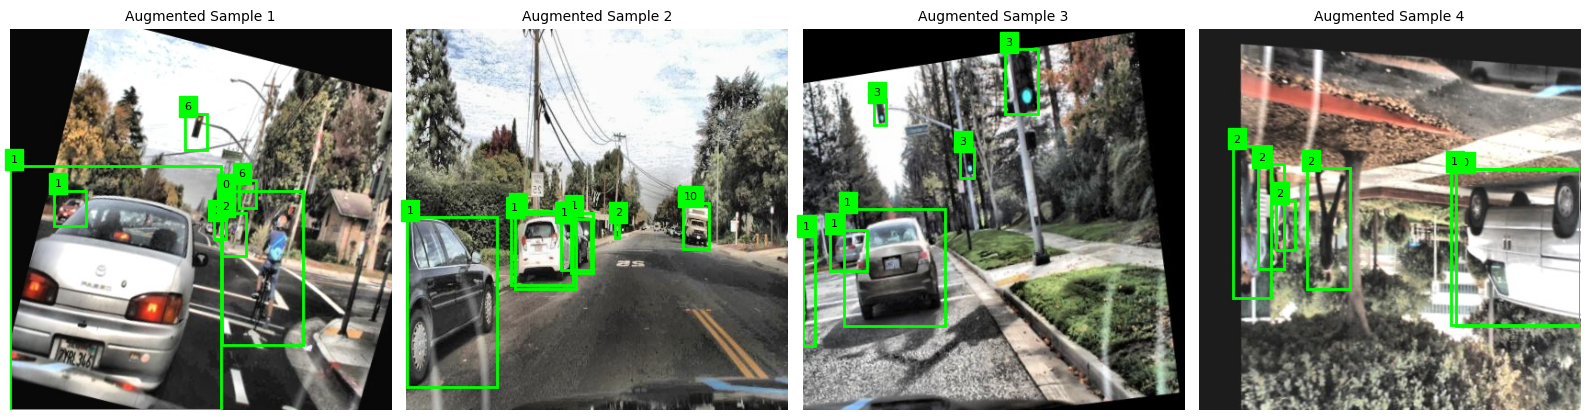

In [12]:

# --- VISUAL QA OF AUGMENTED IMAGES ---
import random
from matplotlib.patches import Rectangle
# Helper function to convert YOLO (0-1) to Pixel coordinates
def yolo_to_pixels(yolo_box, img_w, img_h):
    x_c, y_c, w, h = yolo_box
    x_min = int((x_c - w / 2.0) * img_w)
    y_min = int((y_c - h / 2.0) * img_h)
    x_max = int((x_c + w / 2.0) * img_w)
    y_max = int((y_c + h / 2.0) * img_h)
    return x_min, y_min, x_max, y_max

aug_files = glob.glob(os.path.join(OUT_IMG, "*.*"))
aug_files = [p for p in aug_files if p.lower().endswith((".jpg",".jpeg",".png"))]

if aug_files:
    samples=random.sample(aug_files,min(4,len(aug_files)))
    plt.figure(figsize=(16,5))
    for i,img_p in enumerate(samples):
        img=cv2.imread(img_p)
        if img is None: continue
        h,w=img.shape[:2]
        lbl_p=os.path.join(OUT_LBL, os.path.splitext(os.path.basename(img_p))[0]+".txt")
        fig_ax=plt.subplot(1,4,i+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Augmented Sample {i+1}", fontsize=10)

        if os.path.exists(lbl_p):
            with open(lbl_p,'r') as f:
                for line in f:
                    parts=line.strip().split()
                    if len(parts)<5: continue
                    cls, xc, yc, bw, bh=parts[:5]
                    try:
                        cls=int(float(cls))
                        xc,yc,bw,bh=map(float,(xc,yc,bw,bh))
                    except:
                        continue

                    x1, y1, x2, y2 = yolo_to_pixels((xc, yc, bw, bh), w, h)

                    rect=Rectangle((x1,y1),x2-x1,y2-y1,linewidth=2,edgecolor='lime',facecolor='none')
                    fig_ax.add_patch(rect)

                    label_txt=class_names[cls] if 0<=cls<len(class_names) else str(cls)
                    fig_ax.text(x1,y1-4,label_txt,fontsize=8,color='black',backgroundcolor='lime')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No augmented images found for visualization.")


In [14]:

# --- FINAL PACKAGING ---
import shutil
# Set final directory name
final_train_dir=os.path.join(dataset_location,"train_final_classaware")
final_images=os.path.join(final_train_dir,"images")
final_labels=os.path.join(final_train_dir,"labels")

# Clear and recreate final directory
if os.path.exists(final_train_dir):
    shutil.rmtree(final_train_dir)
os.makedirs(final_images,exist_ok=True)
os.makedirs(final_labels,exist_ok=True)

# Copy preprocessed (original size + resized) and augmented data
print("➡️ Merging preprocessed and augmented data into final folder...")
count = 0
# Folders to merge: preprocessed is the "base" of resized data, aug is the generated data
for folder in [preprocessed_img_dir, OUT_IMG]:
    for p in glob.glob(os.path.join(folder,"*.*")):
        if p.lower().endswith((".jpg",".jpeg",".png")):
            shutil.copy2(p,os.path.join(final_images,os.path.basename(p)))
            count += 1

for folder in [preprocessed_lbl_dir, OUT_LBL]:
    for p in glob.glob(os.path.join(folder,"*.txt")):
        shutil.copy2(p,os.path.join(final_labels,os.path.basename(p)))

print(f"   - Total images in final set: {count}")

archive_name="Milestone1_Final_Dataset_Preprocessed_ClassAware"
shutil.make_archive(archive_name,'zip',root_dir=final_train_dir)
print(f"🎉 Export complete: {archive_name}.zip")


➡️ Merging preprocessed and augmented data into final folder...
   - Total images in final set: 108471
🎉 Export complete: Milestone1_Final_Dataset_Preprocessed_ClassAware.zip
